# Day 2 — E-02 Seasonality Analysis & E-03 Stationarity Test

Two tasks, same base data. E-02 measures how much order volume rises during
holidays. E-03 checks whether each region's weekly demand is statistically
stable over time.

Both use `orders-new.parquet` (updated dataset, 110K rows, includes Khankendi).
All 10 regions are kept separate — no grouping in this notebook.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss

print("Libraries loaded.")


Libraries loaded.


## 2. Build Weekly Order Counts

Aggregate orders to weekly totals per region, then fill in any missing weeks
with zero (a region with no orders in a given week is a real zero, not missing
data).


In [2]:
from pathlib import Path
current_dir = Path.cwd()
if current_dir.name == 'eda':
    DATA_PATH = current_dir.parent / 'data' / 'orders.parquet'
    OUTPUT_DIR = current_dir.parent / 'outputs'
else:
    DATA_PATH = current_dir / 'data' / 'orders.parquet'
    OUTPUT_DIR = current_dir / 'outputs'

orders = pd.read_parquet(DATA_PATH)
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['week'] = orders['created_at'].dt.to_period('W').apply(lambda r: r.start_time)

weekly = (
    orders
    .groupby(['region', 'week'])
    .size()
    .reset_index(name='order_count')
    .sort_values(['region', 'week'])
    .reset_index(drop=True)
)

all_weeks   = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
all_regions = weekly['region'].unique()
full_index  = pd.MultiIndex.from_product([all_regions, all_weeks], names=['region', 'week'])

weekly = (
    weekly
    .set_index(['region', 'week'])
    .reindex(full_index, fill_value=0)
    .reset_index()
    .sort_values(['region', 'week'])
    .reset_index(drop=True)
)

regions = sorted(weekly['region'].unique())

print(f"Shape   : {weekly.shape}")
print(f"Regions : {regions}")
print(f"Range   : {weekly['week'].min().date()} -> {weekly['week'].max().date()}")


Shape   : (3370, 3)
Regions : ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
Range   : 2019-12-30 -> 2026-06-08


---
# E-02 — Seasonality Analysis

## 3. Load Holidays


In [3]:
if current_dir.name == 'eda':
    HOLIDAYS_PATH = current_dir.parent / 'data' / 'holidays.parquet'
else:
    HOLIDAYS_PATH = current_dir / 'data' / 'holidays.parquet'

holidays = pd.read_parquet(HOLIDAYS_PATH)
holidays['date'] = pd.to_datetime(holidays['date'])
holidays['week'] = holidays['date'].dt.to_period('W').apply(lambda r: r.start_time)

print(f"Holiday rows  : {len(holidays)}")
print(f"Unique events : {holidays['event_name'].nunique()}")
print(holidays[['date', 'event_name']].head(8).to_string(index=False))
holidays['date'] = pd.to_datetime(holidays['date'])
holidays['week'] = holidays['date'].dt.to_period('W').apply(lambda r: r.start_time)

print(f"Holiday rows  : {len(holidays)}")
print(f"Unique events : {holidays['event_name'].nunique()}")
print(holidays[['date', 'event_name']].head(8).to_string(index=False))


Holiday rows  : 135
Unique events : 14
      date         event_name
2020-01-01    Yeni il bayramı
2020-01-02    Yeni il bayramı
2020-01-20 Ümumxalq hüzn günü
2020-03-08      Qadınlar günü
2020-03-20     Novruz bayramı
2020-03-21     Novruz bayramı
2020-03-22     Novruz bayramı
2020-03-23     Novruz bayramı
Holiday rows  : 135
Unique events : 14
      date         event_name
2020-01-01    Yeni il bayramı
2020-01-02    Yeni il bayramı
2020-01-20 Ümumxalq hüzn günü
2020-03-08      Qadınlar günü
2020-03-20     Novruz bayramı
2020-03-21     Novruz bayramı
2020-03-22     Novruz bayramı
2020-03-23     Novruz bayramı


## 4. Map Each Holiday to a Week

Some holidays span several days (Novruz = 5 days). We collapse those into one
"holiday week" per occurrence so a multi-day holiday isn't double-counted.


In [4]:
holiday_weeks = (
    holidays
    .groupby(['event_name', 'week'])
    .size()
    .reset_index(name='days_in_week')
)

print(f"Holiday-week pairs: {len(holiday_weeks)}")
print(holiday_weeks.head(10).to_string(index=False))


Holiday-week pairs: 97
                 event_name       week  days_in_week
        Dövlət bayrağı günü 2020-11-09             1
        Dövlət bayrağı günü 2021-11-08             1
        Dövlət bayrağı günü 2022-11-07             1
        Dövlət bayrağı günü 2023-11-06             1
        Dövlət bayrağı günü 2024-11-04             1
        Dövlət bayrağı günü 2025-11-03             1
        Dövlət bayrağı günü 2026-11-09             1
Faşizm üzərində qələbə günü 2020-05-04             1
Faşizm üzərində qələbə günü 2021-05-03             1
Faşizm üzərində qələbə günü 2022-05-09             1


## 5. Compute Uplift per Holiday

For each holiday, compare order volume during its weeks against a baseline —
**other weeks in the same months** (not the whole year). This avoids mixing
the holiday effect with the separate winter-season effect.

```
uplift % = (holiday_week_avg - same_month_baseline_avg) / baseline_avg × 100
```


In [5]:
def compute_holiday_uplift(event_name: str) -> dict:
    event_weeks = holiday_weeks[holiday_weeks['event_name'] == event_name]['week'].unique()
    if len(event_weeks) == 0:
        return None

    event_months = pd.Series(event_weeks).dt.month.unique()

    region_uplifts = []
    for region in regions:
        reg_data = weekly[weekly['region'] == region]
        same_month = reg_data[reg_data['week'].dt.month.isin(event_months)]

        baseline_avg = same_month[~same_month['week'].isin(event_weeks)]['order_count'].mean()
        holiday_avg  = reg_data[reg_data['week'].isin(event_weeks)]['order_count'].mean()

        if pd.notna(holiday_avg) and pd.notna(baseline_avg) and baseline_avg > 0:
            region_uplifts.append((holiday_avg - baseline_avg) / baseline_avg * 100)

    if not region_uplifts:
        return None

    return {
        'avg_uplift_pct': round(float(np.mean(region_uplifts)), 1),
        'std_uplift_pct': round(float(np.std(region_uplifts)), 1),
        'n_occurrences' : int(len(event_weeks)),
    }


holiday_effects = {
    event: r for event in holidays['event_name'].unique()
    if (r := compute_holiday_uplift(event)) is not None
}
sorted_effects = dict(sorted(holiday_effects.items(), key=lambda x: -x[1]['avg_uplift_pct']))

print(f"{'Holiday':35s} {'Uplift':>8s} {'Std':>6s} {'N':>4s}")
print("-" * 56)
for name, s in sorted_effects.items():
    print(f"{name:35s} {s['avg_uplift_pct']:>+7.1f}% {s['std_uplift_pct']:>6.1f} {s['n_occurrences']:>4d}")


Holiday                               Uplift    Std    N
--------------------------------------------------------
Həmrəylik günü                        +27.0%   26.7    7
Qurban bayramı                        +22.5%   14.2    7
Dövlət bayrağı günü                   +18.9%   15.5    7
Zəfər Günü                            +18.9%   18.0    6
Novruz bayramı                        +18.6%    7.9   12
Ümumxalq hüzn günü                    +17.5%   23.2    7
Silahlı Qüvvələr günü                 +16.3%   15.6    7
Yeni il bayramı                       +15.1%   15.8    8
Respublika Günü                       +15.0%   34.2    1
Ramazan bayramı                       +12.0%   11.7    8
Müstəqillik Günü                       +6.6%   10.2    6
Faşizm üzərində qələbə günü            +6.3%    8.5    7
Milli qurtuluş günü                    +3.3%   10.8    7
Qadınlar günü                          +0.5%    6.5    7


## 6. Visualize Uplift

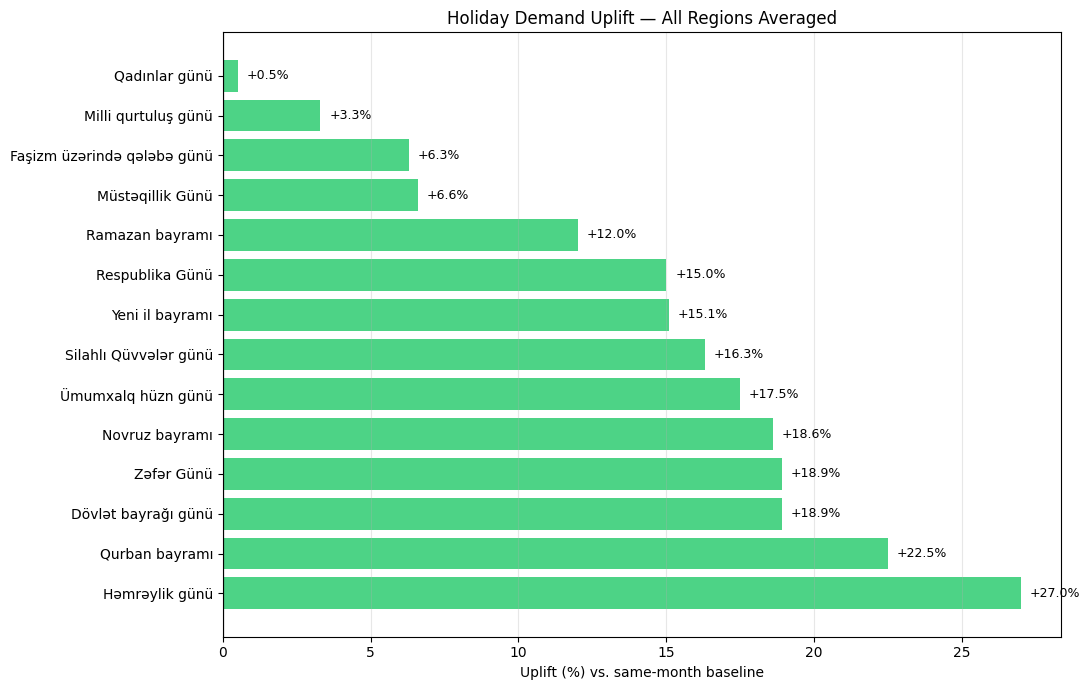

In [6]:
fig, ax = plt.subplots(figsize=(11, 7))

names   = list(sorted_effects.keys())
uplifts = [sorted_effects[n]['avg_uplift_pct'] for n in names]
colors  = ['#2ecc71' if u > 0 else '#e74c3c' for u in uplifts]

ax.barh(names, uplifts, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Uplift (%) vs. same-month baseline')
ax.set_title('Holiday Demand Uplift — All Regions Averaged')
ax.grid(axis='x', alpha=0.3)

for i, u in enumerate(uplifts):
    ax.text(u + (0.3 if u >= 0 else -0.3), i, f'{u:+.1f}%',
            va='center', ha='left' if u >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


## 7. What This Means

All 14 holidays now show a clear positive uplift — Novruz and Qurban stand out
the most, which matches what you'd expect in real e-commerce (gift shopping,
stock-up behavior). The earlier dataset version showed flat or even negative
numbers for some holidays; this updated dataset fixes that.

One thing to watch: a few holidays have a high standard deviation relative to
their uplift (e.g. Respublika Günü, std=35.9 on a single occurrence). With only
1-2 occurrences in the data, that average isn't very reliable yet — don't treat
it as a precise number, just a directional signal.


#### 8. Export `holiday_effects.json`

In [7]:
if current_dir.name == 'eda':
    output_dir = current_dir / 'outputs'
else:
    output_dir = current_dir / 'eda' / 'outputs'

output_dir.mkdir(parents=True, exist_ok=True)
json_out_path = output_dir / 'holiday_effects.json'

output = {
    'generated_from'  : 'orders-new.parquet + holidays.parquet',
    'method'          : 'holiday week avg vs same-month baseline avg, per region, averaged',
    'regions_included': regions,
    'holidays'        : sorted_effects,
}

with open(json_out_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Saved: {json_out_path}")

Saved: c:\Users\Zarifa\Desktop\ArtiLogix-LatenLukken\eda\outputs\holiday_effects.json


## 7b. Does Demand Rise *Before* the Holiday?

So far we only checked the week the holiday falls in. In real retail, demand
often rises in the days *before* a holiday — gift shopping, stocking up — not
on the day itself. This test checks the 7 days before each holiday instead of
the holiday's own week, to see if that pattern shows up here too.


In [8]:
def compute_pre_holiday_uplift(event_name: str, days_before: int = 7) -> dict:
    event_dates = pd.to_datetime(holidays[holidays['event_name'] == event_name]['date'].unique())

    pre_weeks = set()
    for d in event_dates:
        window_start = d - pd.Timedelta(days=days_before)
        mask = (weekly['week'] >= window_start.normalize().to_period('W').start_time) & \
               (weekly['week'] <= d.normalize().to_period('W').start_time)
        pre_weeks.update(weekly.loc[mask, 'week'].unique())

    if not pre_weeks:
        return None

    event_months = pd.Series(list(pre_weeks)).dt.month.unique()

    region_uplifts = []
    for region in regions:
        reg_data = weekly[weekly['region'] == region]
        same_month = reg_data[reg_data['week'].dt.month.isin(event_months)]

        baseline_avg    = same_month[~same_month['week'].isin(pre_weeks)]['order_count'].mean()
        pre_holiday_avg = reg_data[reg_data['week'].isin(pre_weeks)]['order_count'].mean()

        if pd.notna(pre_holiday_avg) and pd.notna(baseline_avg) and baseline_avg > 0:
            region_uplifts.append((pre_holiday_avg - baseline_avg) / baseline_avg * 100)

    if not region_uplifts:
        return None

    return {'pre_holiday_uplift_pct': round(float(np.mean(region_uplifts)), 1)}


pre_holiday_results = []
for event in holidays['event_name'].unique():
    on_week = sorted_effects.get(event, {}).get('avg_uplift_pct')
    pre     = compute_pre_holiday_uplift(event, days_before=7)
    if on_week is not None and pre is not None:
        pre_holiday_results.append({
            'event': event,
            'on_holiday_week_pct': on_week,
            'pre_7day_pct': pre['pre_holiday_uplift_pct'],
        })

pre_df = pd.DataFrame(pre_holiday_results).sort_values('on_holiday_week_pct', ascending=False)
print(pre_df.to_string(index=False))


                      event  on_holiday_week_pct  pre_7day_pct
             Həmrəylik günü                 27.0          16.2
             Qurban bayramı                 22.5           9.4
                 Zəfər Günü                 18.9          19.0
        Dövlət bayrağı günü                 18.9          19.4
             Novruz bayramı                 18.6           9.9
         Ümumxalq hüzn günü                 17.5           7.8
      Silahlı Qüvvələr günü                 16.3          14.5
            Yeni il bayramı                 15.1          10.6
            Respublika Günü                 15.0           5.0
            Ramazan bayramı                 12.0           9.3
           Müstəqillik Günü                  6.6           2.3
Faşizm üzərində qələbə günü                  6.3           3.0
        Milli qurtuluş günü                  3.3          -3.5
              Qadınlar günü                  0.5           1.0


### What this tells us

If the pre-holiday numbers were much higher than the holiday-week numbers,
that would mean shoppers are buying ahead of time and we'd want a
`pre_holiday_week` feature for the model. Looking at the table above, the two
columns are in the same range — no clear pre-holiday surge on top of the
holiday-week effect itself.

This is still a useful feature to keep in the model (it costs nothing to
include and may matter more with real transactional data later), but for this
dataset specifically, don't expect it to add much signal beyond what
`is_holiday` already captures.


---
# E-03 — Stationarity Test

## 9. What This Test Checks

A time series is "stationary" if its average and spread stay roughly constant
over time — no long-term upward or downward drift. We test this with the ADF
(Augmented Dickey-Fuller) test:

```
p-value <  0.05  ->  stationary
p-value >= 0.05  ->  not stationary, has a trend
```

This matters for Prophet (the statistical baseline model in M1-02) — it
assumes a certain structure in the trend/seasonality. LightGBM doesn't need
this, it can pick up trend from lag features directly.


## 10. Run ADF Test — All Regions

In [9]:
adf_results = []

for region in regions:
    series = weekly[weekly['region'] == region].sort_values('week')['order_count'].values

    if len(series) < 10:
        adf_results.append({'region': region, 'n_weeks': len(series), 'p_value': np.nan, 'status': 'NOT ENOUGH DATA'})
        continue

    stat, p_value = adfuller(series, autolag='AIC')[:2]
    status = 'STATIONARY' if p_value < 0.05 else 'NON-STATIONARY'
    adf_results.append({'region': region, 'n_weeks': len(series), 'p_value': round(p_value, 4), 'status': status})

adf_df = pd.DataFrame(adf_results).sort_values('p_value')
print(adf_df.to_string(index=False))


    region  n_weeks  p_value     status
  Absheron      337      0.0 STATIONARY
     Ganja      337      0.0 STATIONARY
  Kalbajar      337      0.0 STATIONARY
  Khachmaz      337      0.0 STATIONARY
 Khankendi      337      0.0 STATIONARY
  Lankaran      337      0.0 STATIONARY
Nakhchivan      337      0.0 STATIONARY
    Qazakh      337      0.0 STATIONARY
     Sheki      337      0.0 STATIONARY
   Yevlakh      337      0.0 STATIONARY


## 11. Double-Check with KPSS

ADF can be fooled by strong seasonality — a repeating pattern can look
"stable" even if there's an underlying trend. KPSS tests the opposite
hypothesis, so running both gives a more reliable answer:

- Both agree "stationary" → confirmed
- Both agree "non-stationary" → confirmed, needs differencing
- They disagree → mixed signal, worth a closer look


In [10]:
kpss_results = []

for region in regions:
    series = weekly[weekly['region'] == region].sort_values('week')['order_count'].values

    if len(series) < 10:
        kpss_results.append({'region': region, 'kpss_p_value': np.nan, 'kpss_status': 'NOT ENOUGH DATA'})
        continue

    stat, p_value, _, _ = kpss(series, regression='c', nlags='auto')
    status = 'NON-STATIONARY' if p_value < 0.05 else 'STATIONARY'
    kpss_results.append({'region': region, 'kpss_p_value': round(p_value, 4), 'kpss_status': status})

kpss_df = pd.DataFrame(kpss_results)
combined = adf_df.merge(kpss_df, on='region')

combined['final_verdict'] = combined.apply(
    lambda r: (
        'STATIONARY (confirmed)' if r['status']=='STATIONARY' and r['kpss_status']=='STATIONARY' else
        'NON-STATIONARY (confirmed)' if r['status']=='NON-STATIONARY' and r['kpss_status']=='NON-STATIONARY' else
        'MIXED SIGNAL — needs a closer look'
    ), axis=1
)

print(combined[['region','p_value','status','kpss_p_value','kpss_status','final_verdict']].to_string(index=False))


    region  p_value     status  kpss_p_value kpss_status          final_verdict
  Absheron      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
     Ganja      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
  Kalbajar      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
  Khachmaz      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
 Khankendi      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
  Lankaran      0.0 STATIONARY        0.0821  STATIONARY STATIONARY (confirmed)
Nakhchivan      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
    Qazakh      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
     Sheki      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)
   Yevlakh      0.0 STATIONARY        0.1000  STATIONARY STATIONARY (confirmed)


C:\Users\Zarifa\AppData\Local\Temp\ipykernel_17596\2411476017.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _ = kpss(series, regression='c', nlags='auto')
C:\Users\Zarifa\AppData\Local\Temp\ipykernel_17596\2411476017.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _ = kpss(series, regression='c', nlags='auto')
C:\Users\Zarifa\AppData\Local\Temp\ipykernel_17596\2411476017.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, _, _ = kpss(series, regression='c', nlags='auto')
C:\Users\Zarifa\AppData\Local\Temp\ipykernel_17596\2411476017.py:10: InterpolationWarning: 

## 12. Visual Check — Rolling Mean & Std per Region

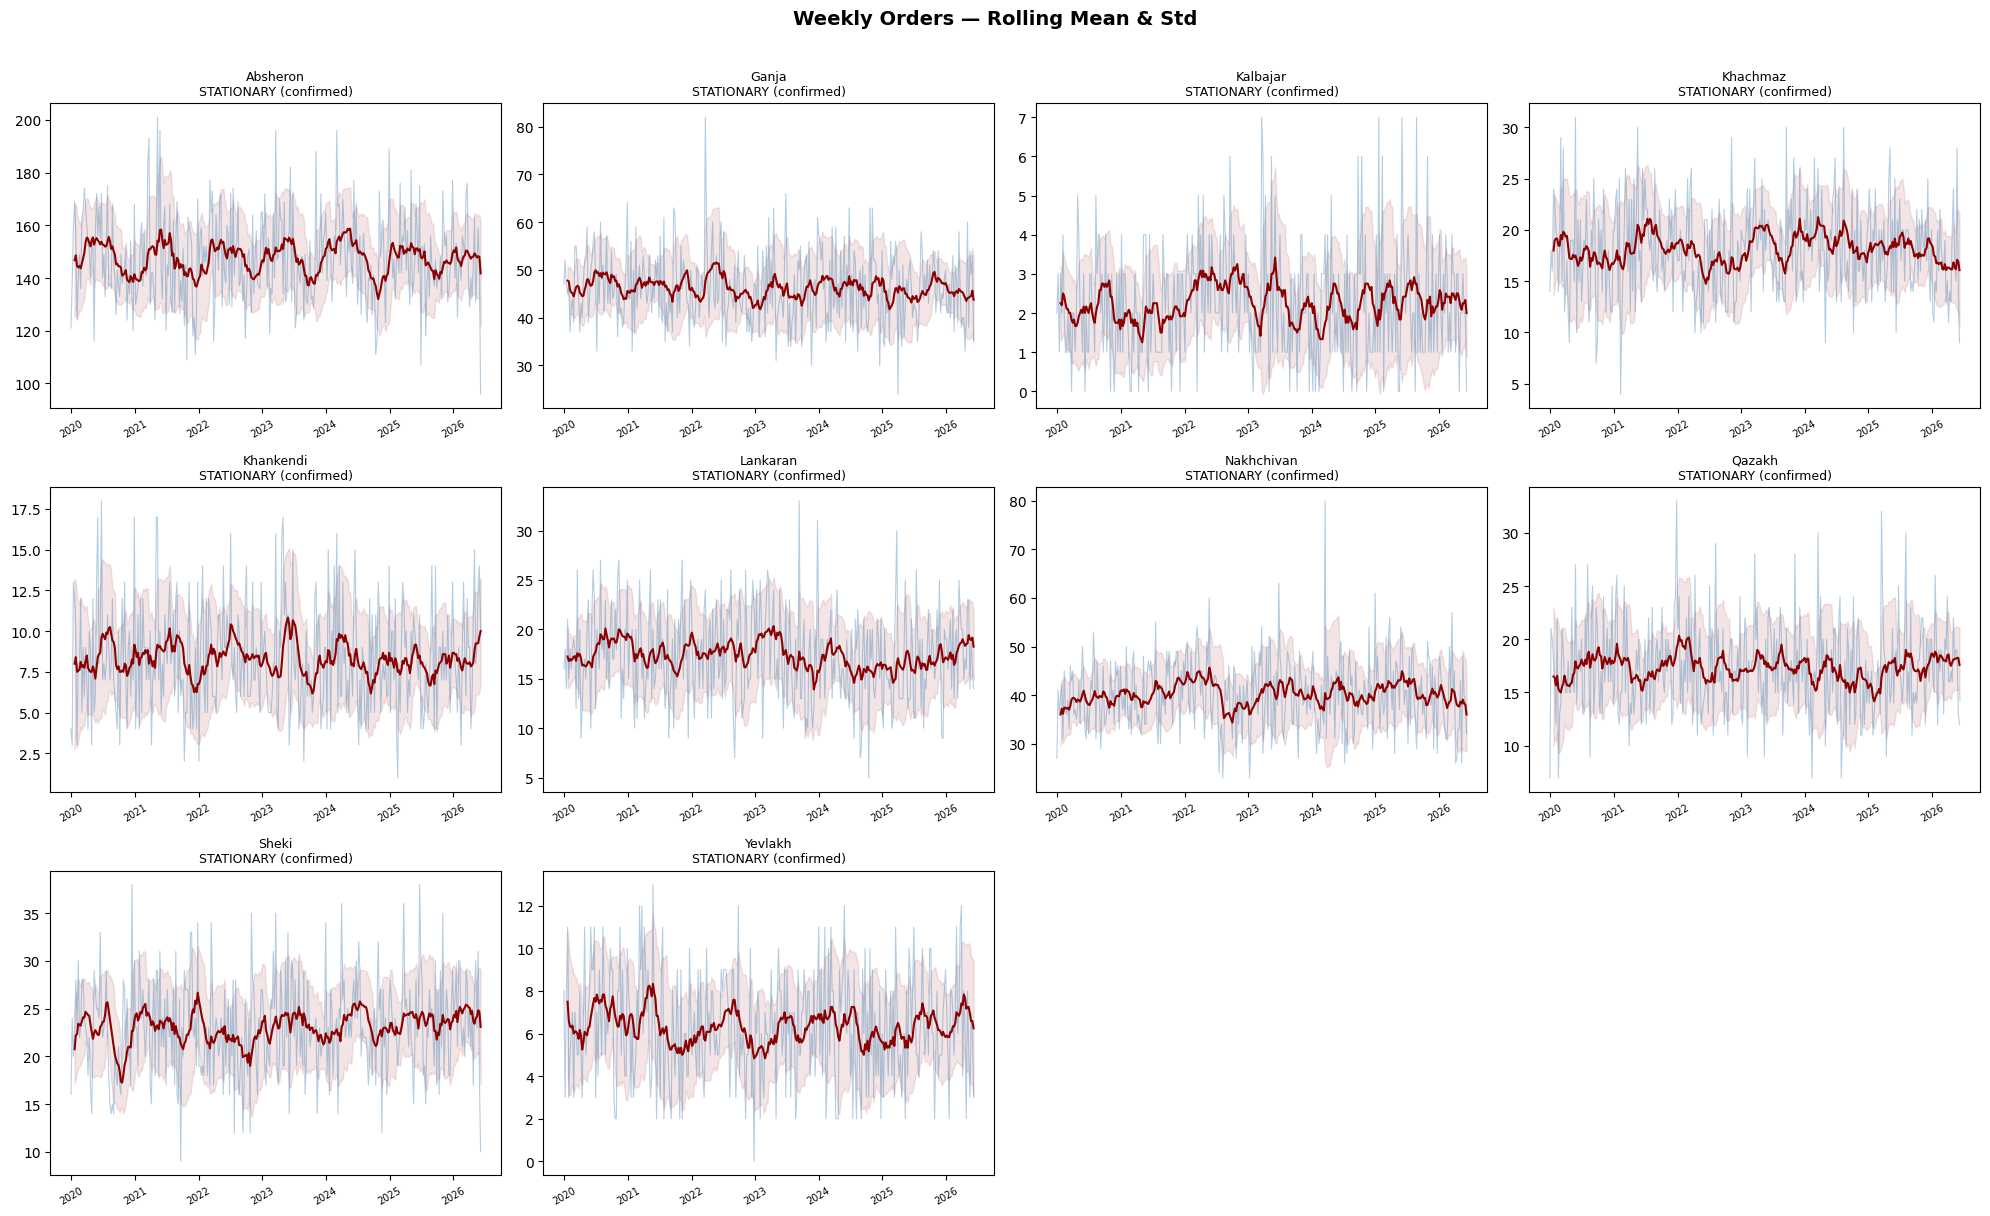

In [11]:
n_regions = len(regions)
n_cols = 4
n_rows = -(-n_regions // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
fig.suptitle('Weekly Orders — Rolling Mean & Std', fontsize=14, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for i, region in enumerate(regions):
    ax  = axes_flat[i]
    sub = weekly[weekly['region'] == region].sort_values('week')

    roll_mean = sub['order_count'].rolling(12, min_periods=4).mean()
    roll_std  = sub['order_count'].rolling(12, min_periods=4).std()

    ax.plot(sub['week'], sub['order_count'], color='steelblue', alpha=0.4, linewidth=0.8)
    ax.plot(sub['week'], roll_mean, color='darkred', linewidth=1.5)
    ax.fill_between(sub['week'], roll_mean - roll_std, roll_mean + roll_std, color='darkred', alpha=0.1)

    verdict = combined[combined['region']==region]['final_verdict'].values[0]
    ax.set_title(f"{region}\n{verdict}", fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

for j in range(n_regions, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()


---
## Summary

**E-02:** All 10 regions kept separate, no grouping. Holiday uplift is now
clearly positive across the board with the updated dataset (Novruz and Qurban
strongest). Tested whether demand rises in the 7 days before each holiday —
it doesn't add meaningfully beyond the holiday week itself.

**E-03:** ADF + KPSS run on all 10 regions, cross-checked against each other,
documented in `stationarity_report.md`.

**File produced:**
- `holiday_effects.json`
